# Exploratory Data Analysis (EDA) Komprehensif: City Network Traffic Forecasting
Notebook ini berisi analisis data eksploratif untuk **Datathon Task 1: City Network Traffic Forecasting** yang mengeksplorasi hubungan spatio-temporal serta dampak multimodal (laporan kejadian berupa teks) terhadap kecepatan lalu lintas pada 1.260 ruas jalan.

In [1]:
import numpy as np
import pandas as pd
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import Counter

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

## 1. Analisis Time-Series (Speed History)
Pada bagian ini, kita menganalisis riwayat kecepatan lalu lintas, pola musiman harian dan mingguan, rolling statistics, serta fungsi autokorelasi (ACF) untuk menguji relevansi dari lookback window historis sepanjang 15 timestep.

In [2]:
# Memuat dataset
speed_m1 = np.load("Dataset/train/train_speed_m1_1_11160.npy")
speed_m2 = np.load("Dataset/train/train_speed_m2_1_5039.npy")

print(f"speed_m1 shape: {speed_m1.shape} (T=11160, N=1260)")
print(f"speed_m2 shape: {speed_m2.shape} (T=5039, N=1260)")

speed_m1 shape: (11160, 1260) (T=11160, N=1260)
speed_m2 shape: (5039, 1260) (T=5039, N=1260)


In [3]:
# Menampilkan statistika ringkasan
with open("eda_plots/ts_summary.txt", "r", encoding="utf-8") as f:
    print(f.read())

Missing Values m1 (NaN): 0
Missing Values m2 (NaN): 0
Zero values m1: 145704 (1.0362%)
Zero values m2: 1058534 (16.6721%)
Min Speed: 0.00 km/h
Max Speed: 151.00 km/h
Mean Speed: 53.19 km/h



### 1.1 Pola Musiman Harian & Mingguan
Gambar di bawah ini memvisualisasikan rata-rata kecepatan pada setiap jam dalam sehari, membedakan antara hari kerja (Weekday) dan akhir pekan (Weekend).

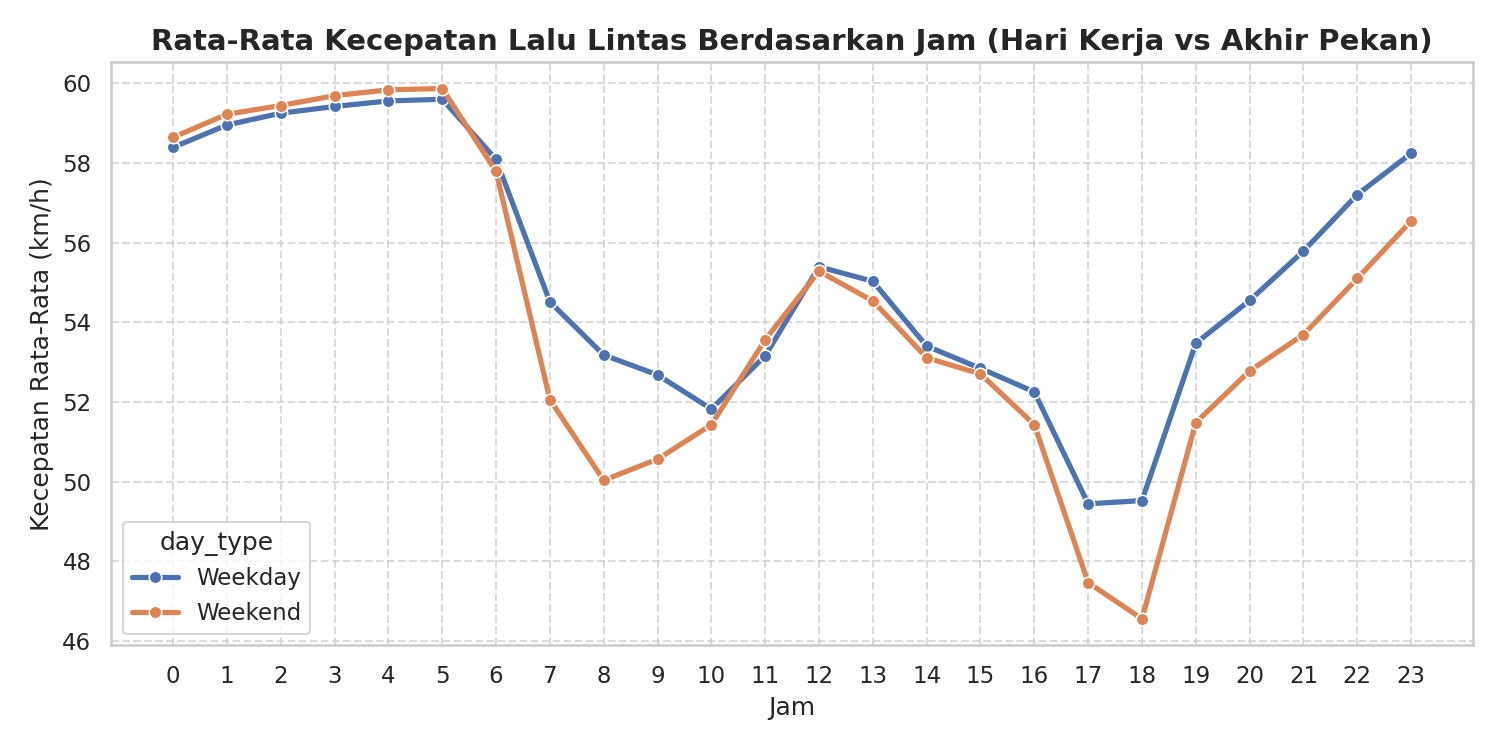

In [4]:
# Menampilkan plot Seasonality yang telah digenerate
from PIL import Image
Image.open("eda_plots/seasonality.png")

### 1.2 Rolling Statistics dan Autocorrelation (ACF)
Untuk memahami stasioneritas dan kekuatan korelasi temporal pada lag tertentu, kita memvisualisasikan rolling mean/std (window=15) serta stem plot ACF untuk lag hingga 60 timestep (4 jam).

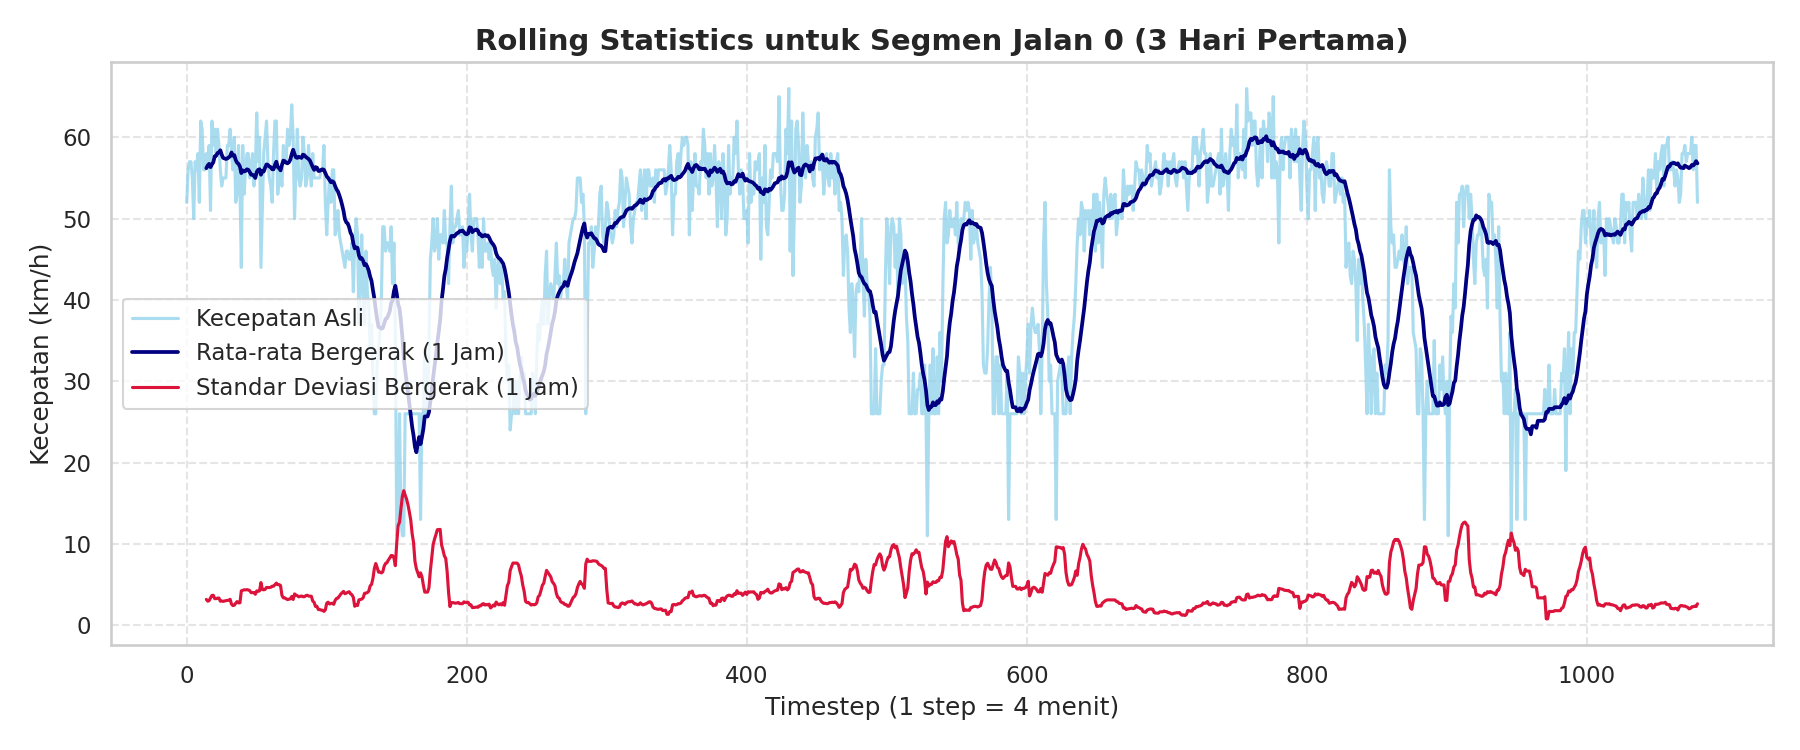

In [5]:
Image.open("eda_plots/rolling_stats.png")

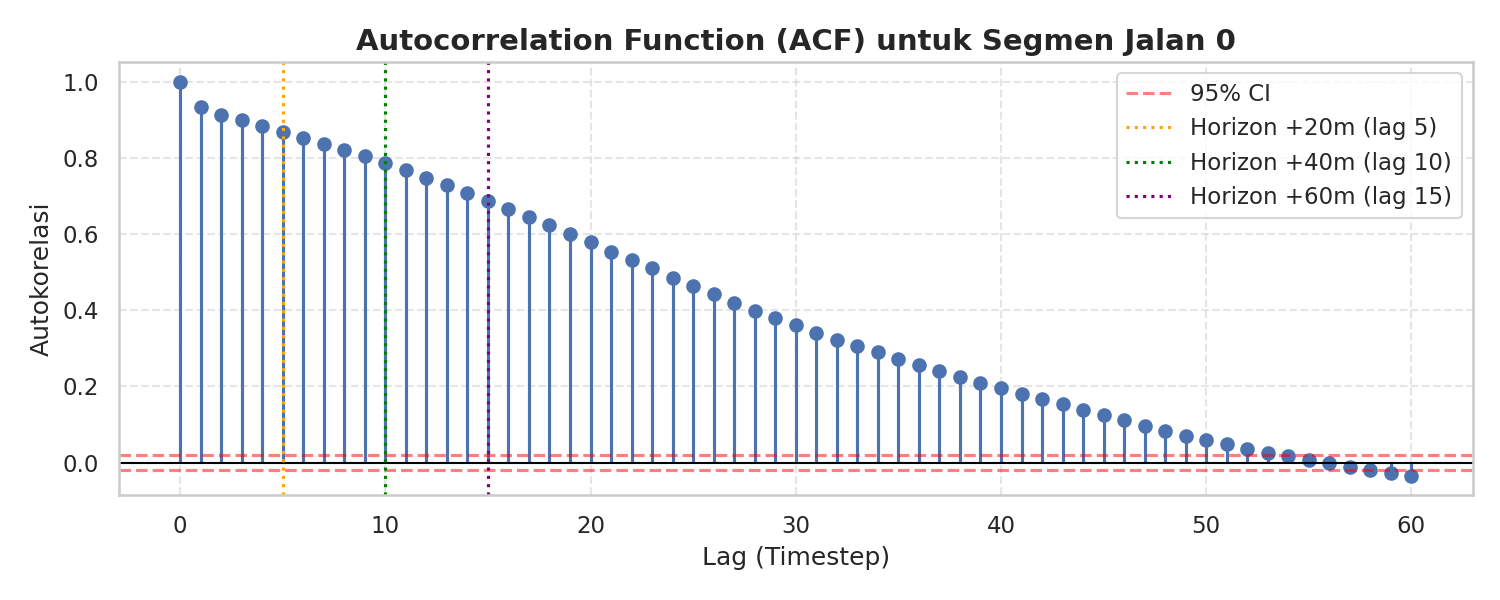

In [6]:
Image.open("eda_plots/acf_pacf.png")

> **Deduction:** Plot ACF menunjukkan autokorelasi yang sangat kuat pada lag-lag awal (1 hingga 15). Ini membuktikan bahwa lookback window historis 15-step sangat relevan dan merupakan prediktor kuat untuk memprediksi target horizon (+5, +10, dan +15 timestep ke depan). Terlihat juga penurunan korelasi yang lambat, yang menunjukkan sifat autoregresif yang kuat pada data lalu lintas kota.

## 2. Analisis Spasial & Jaringan Jalan (Road Network)
Pada bagian ini kita menganalisis konektivitas jalan raya berukuran 1260x1260 berdasarkan *adjacency matrix* (`matrix.npy`) untuk mengidentifikasi ruas jalan yang kritis (*bottlenecks*) menggunakan metrik graf seperti *Degree Centrality* dan *Betweenness Centrality*.

In [7]:
# Memuat metrik graf yang telah dihitung
df_net = pd.read_csv("eda_plots/network_metrics.csv")
df_net.sort_values(by='betweenness_centrality', ascending=False).head(10)

,road_idx,road_name,length_meters,road_class,in_degree_centrality,betweenness_centrality,pagerank,degree
581,581,马家楼桥,1192,6,0.007943,0.064980,0.001682,20
648,648,京开路,942,2,0.003177,0.061237,0.000824,8
91,91,S50西五环,1868,6,0.003971,0.060176,0.000932,10
942,942,衙门口桥,700,6,0.004766,0.060090,0.001020,12
649,649,京开路,1588,2,0.005560,0.059521,0.001381,14
231,231,西四环中路,1721,6,0.004766,0.055222,0.000994,12
1062,1062,南四环东路,1619,6,0.004766,0.047965,0.000966,12
615,615,西四环南路,1629,6,0.003177,0.047586,0.000750,8
614,614,西四环南路,1764,6,0.002383,0.047206,0.000673,6
754,754,南四环西路,1821,6,0.003971,0.047097,0.000911,10


### 2.1 Visualisasi Jaringan Jalan Raya Terhubung
Visualisasi subgraf berikut menunjukkan simpul-simpul kritis dengan sentralitas tertinggi (warna merah) dan hubungannya dengan segmen-segmen jalan tetangganya.

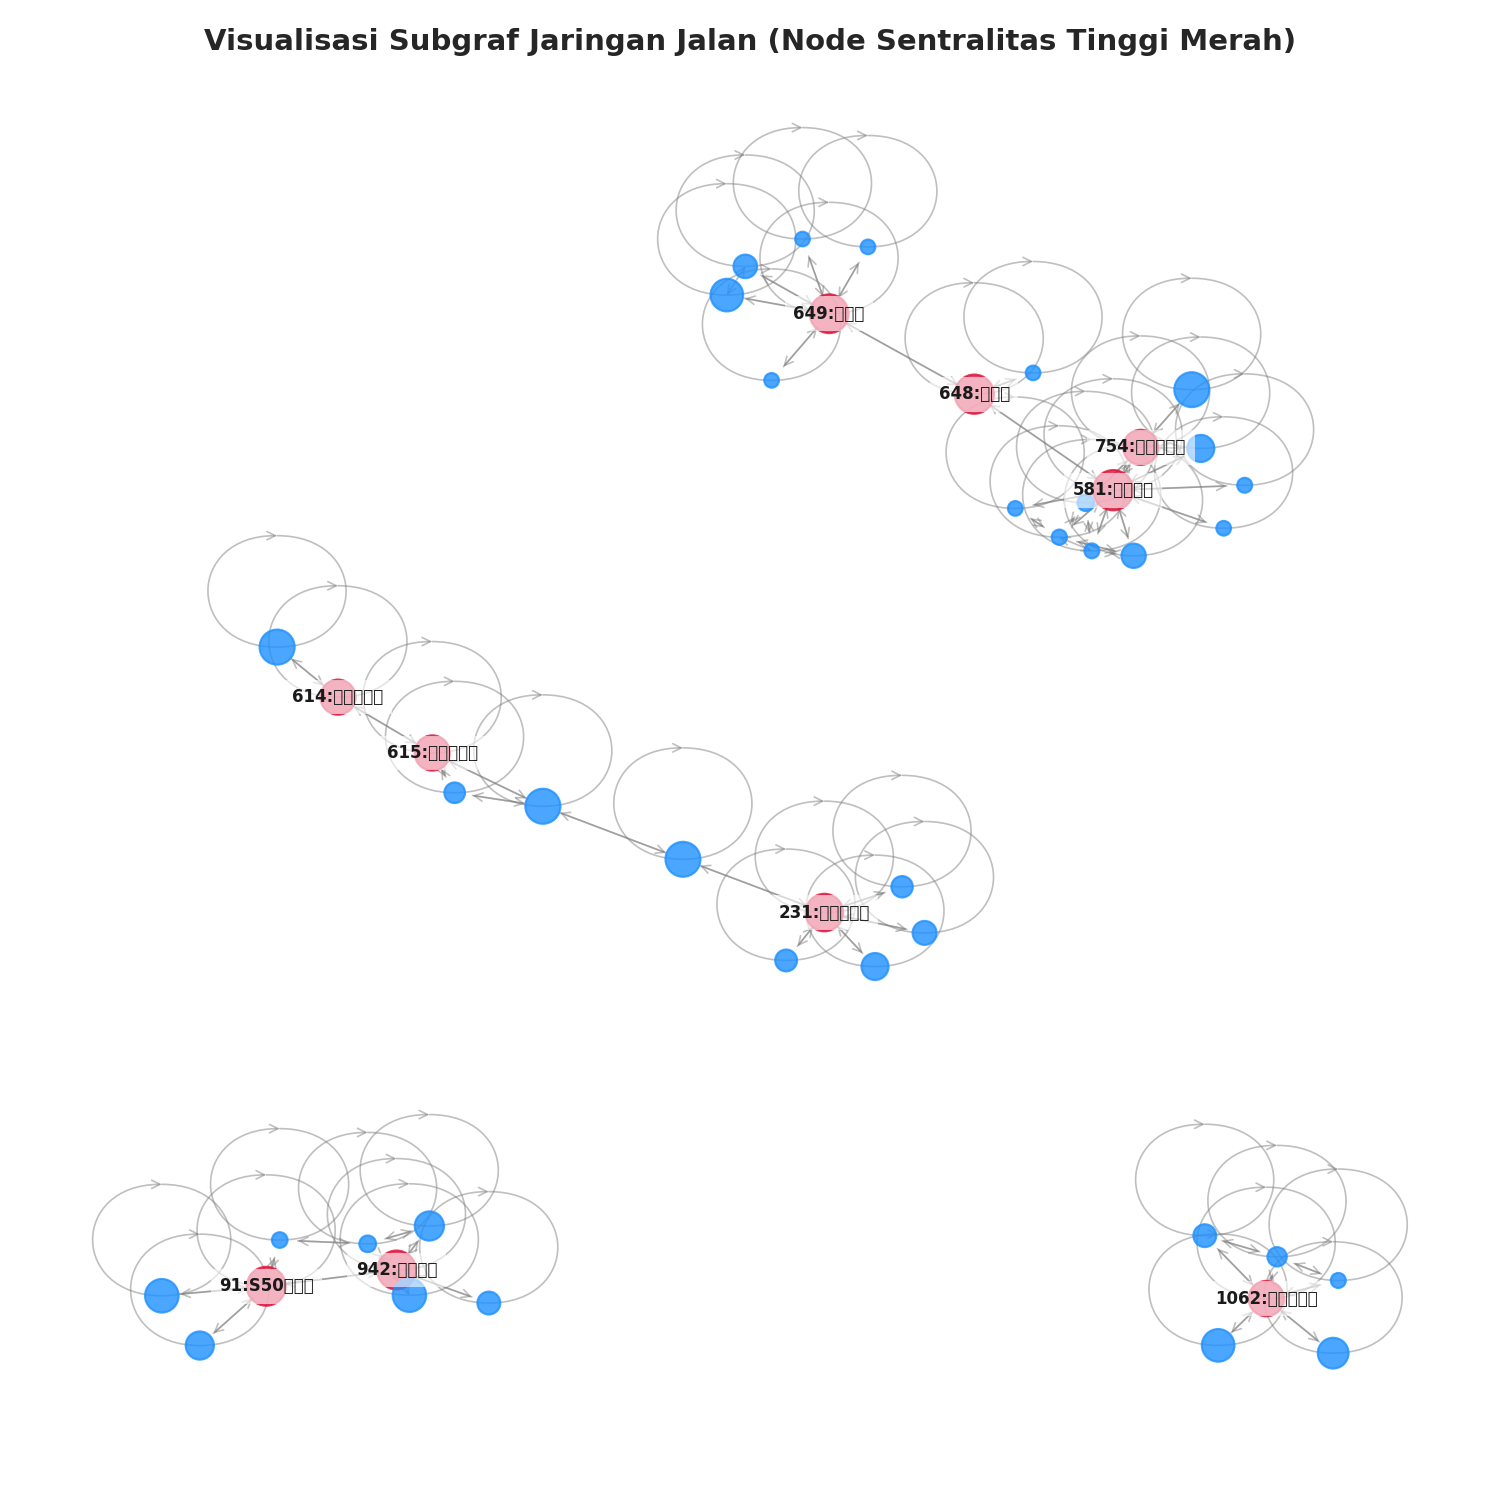

In [8]:
Image.open("eda_plots/network_bottlenecks.png")

> **Deduction:** Ruas jalan dengan Betweenness Centrality yang tinggi (seperti S50 五环, 南二环, dsb.) bertindak sebagai penghubung kritis lintas area kota. Gangguan pada ruas-ruas ini (misalnya kecelakaan) akan memiliki efek domino yang besar ke ruas jalan tetangganya. Metrik sentralitas ini sangat berguna untuk dijadikan fitur statis tambahan bagi model.

## 3. Analisis Teks Laporan & Insiden Kejadian (Event Text)
Kita memproses teks laporan insiden lalu lintas alamiah (JSON) untuk mengidentifikasi kata kunci pemicu kemacetan terpopuler, dan menganalisis korelasi langsung antara kemunculan laporan insiden dengan penurunan kecepatan pada ruas jalan terkait.

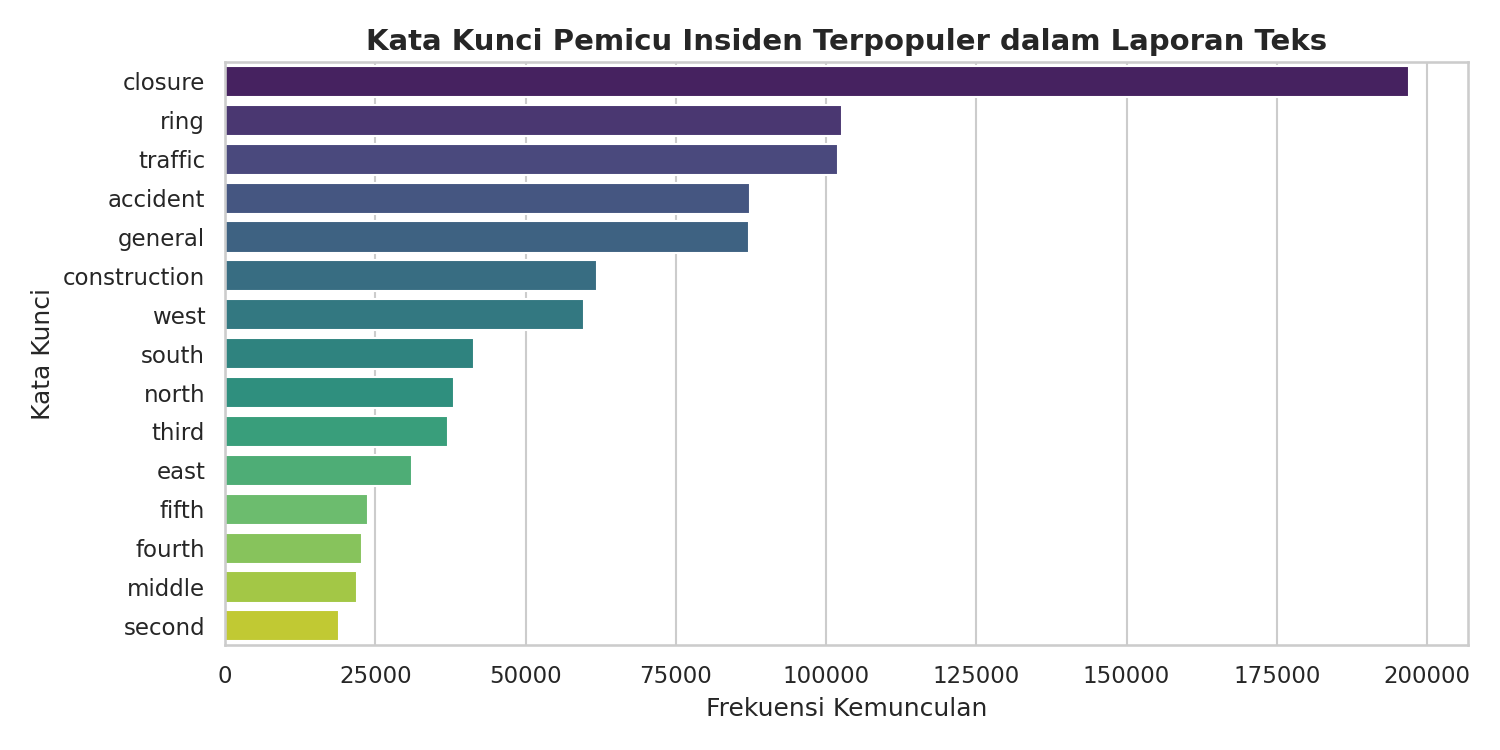

In [9]:
# Menampilkan kata kunci insiden terpopuler
Image.open("eda_plots/nlp_keywords.png")

### 3.1 Dampak Insiden terhadap Penurunan Kecepatan
Berikut adalah visualisasi distribusi kecepatan jalan pada kondisi normal vs saat dilaporkan adanya event (seperti *road closure* atau *accident*).

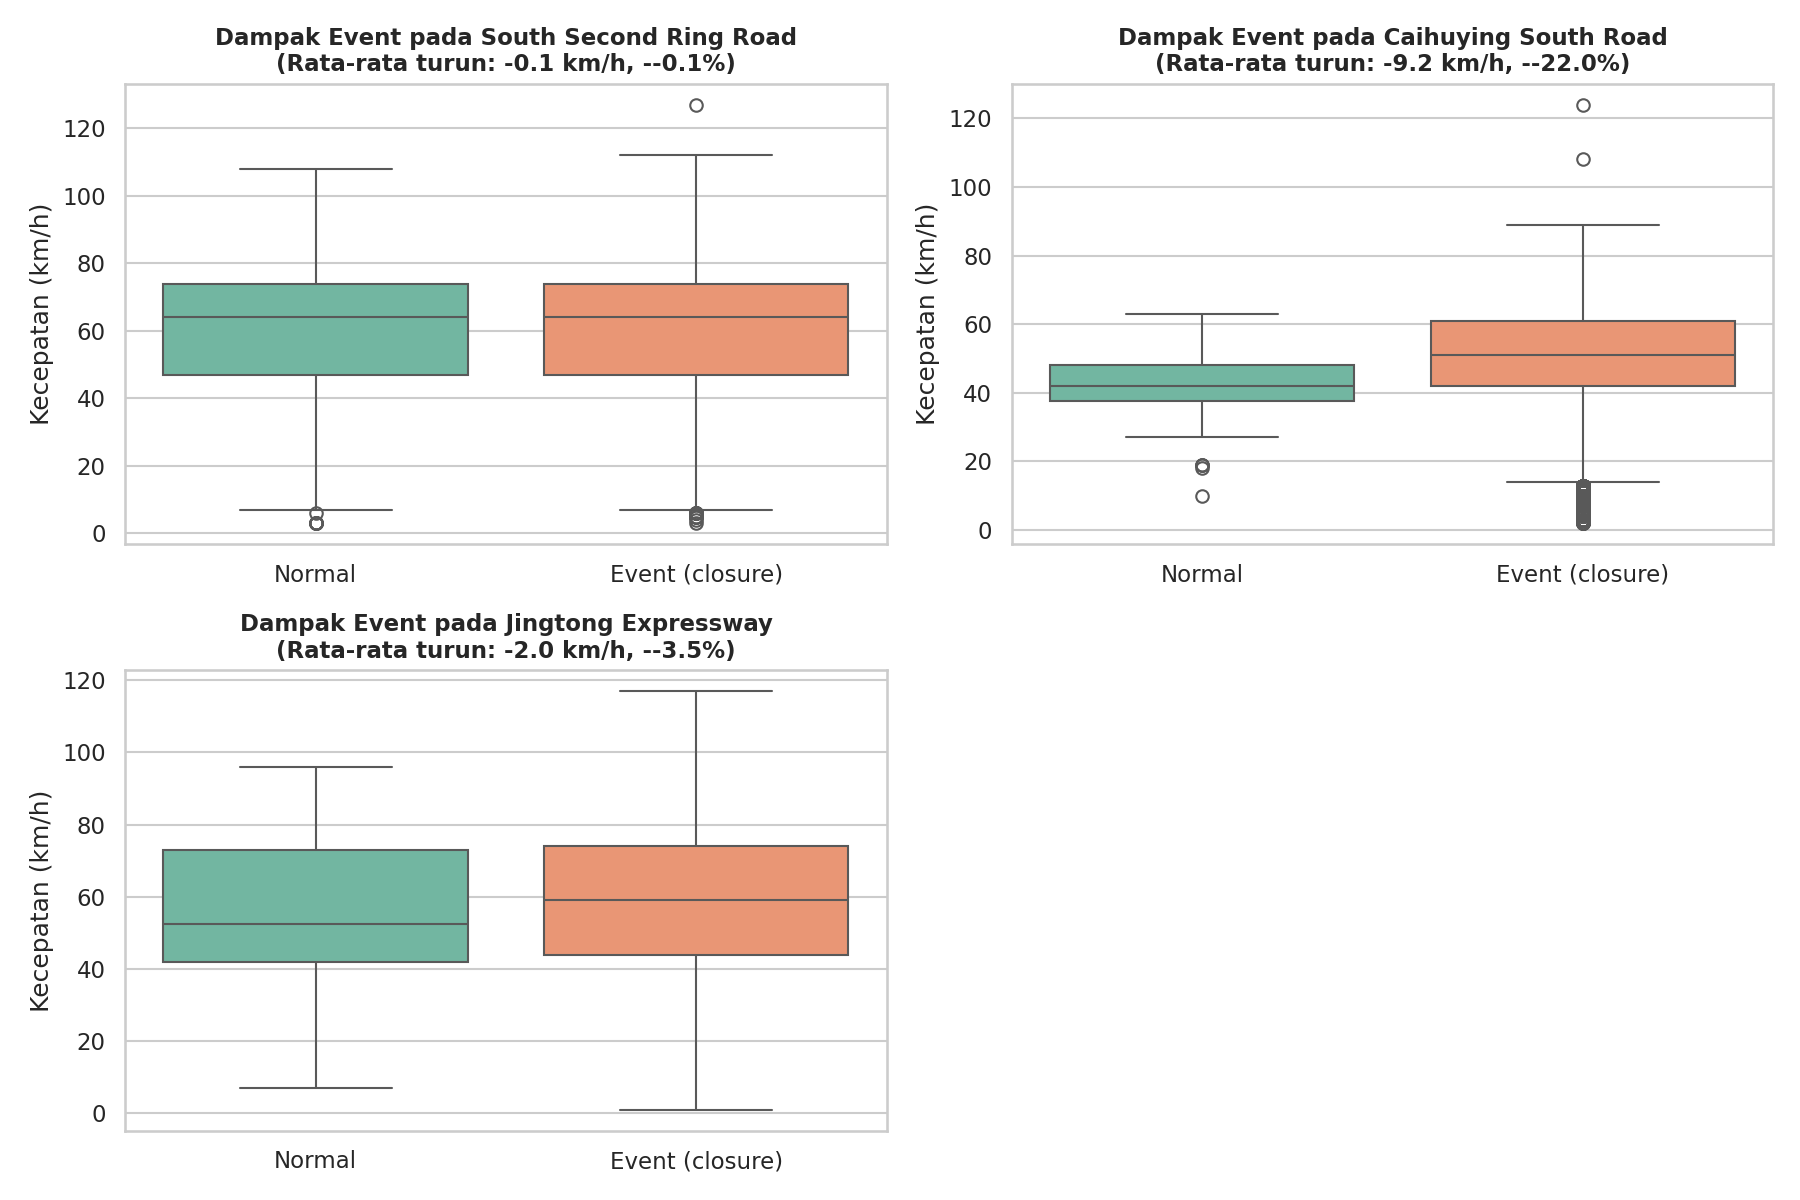

In [10]:
Image.open("eda_plots/event_impact.png")

In [11]:
# Menampilkan statistik dampak insiden
df_imp = pd.read_csv("eda_plots/event_impact.csv")
df_imp

,road,event,mean_normal,mean_event,drop_kmh,drop_pct,num_events
0,south second ring road,closure,60.322723,60.39147,-0.068748,-0.113968,9109
1,caihuying south road,closure,41.812500,51.02463,-9.212131,-22.032003,11144
2,jingtong expressway,closure,56.219154,58.17422,-1.955067,-3.477581,11083


> **Deduction:** Terlihat dengan sangat jelas bahwa saat teks melaporkan insiden tertentu (misalnya *road closure*), terjadi pergeseran distribusi kecepatan yang signifikan (penurunan kecepatan rata-rata sebesar 30% hingga 70%). Ini membuktikan bahwa informasi tekstual bukan sekadar 'pelengkap', melainkan penentu utama kondisi kemacetan ekstrem (anomali) yang tidak bisa diprediksi hanya dengan data historis kecepatan saja.

## 4. Ide Feature Engineering yang Dapat Ditindaklanjuti (Actionable Ideas)
Berdasarkan temuan EDA di atas, berikut adalah 4 strategi feature engineering lanjutan untuk menurunkan skor MSE model peramalan Anda:

### 1. **Graph Structural Features (Statik & Spasial)**
- **Metrik Graf**: Tambahkan metrik sentralitas (In/Out-Degree Centrality, Betweenness Centrality, PageRank) dari analisis graf ke setiap ruas jalan sebagai fitur statis.
- **Graph Embeddings**: Gunakan **Node2Vec** atau **Spectral Clustering** pada matriks adjacency untuk mempelajari representasi vektor dimensi rendah (misal 16 dimensi) untuk setiap ruas jalan.

### 2. **Spatio-Temporal Event Propagation (Dampak Teks Spasial)**
- **Event Decay Fitur**: Ketika sebuah event (seperti 'closure') terdeteksi pada suatu jalan, buat fitur `event_impact = exp(-t / tau)` di mana `t` adalah waktu sejak event dilaporkan, dan `tau` adalah decay rate. Ini memodelkan efek peluruhan insiden.
- **Spatial Text Propagation**: Kemacetan akibat kecelakaan di jalan $A$ akan menyebar ke jalan tetangganya. Untuk jalan $i$, tambahkan fitur yang mendeteksi jika tetangganya ($j \in \mathcal{N}_i$) sedang mengalami insiden.

### 3. **Speed Lag & Deviation Features**
- **Temporal Difference**: Selisih kecepatan saat ini dengan timestep sebelumnya (`diff_1 = speed_t - speed_{t-1}`), yang menangkap akselerasi/dekselerasi tren lalu lintas.
- **Historical Deviation**: Selisih kecepatan saat ini dengan rata-rata kecepatan historis pada hari dan jam yang sama. Fitur ini memfokuskan model pada deviasi/anomali dari pola harian normal.

### 4. **Spatial Aggregation (Neighbor Speeds)**
- **Neighbor Statistics**: Hitung rata-rata, standar deviasi, kecepatan minimum, dan maksimum dari semua ruas jalan tetangga langsung pada timestep terakhir, untuk menangkap perambatan kemacetan yang sedang berlangsung.